# 🚲 Chicago Divvy Bikes: Przewidywanie popytu za pomocą ML
**Autor:** Dawid Kaczyński oraz Bartłomiej Ślesiński

**Streszczenie Projektu:**
Celem tego projektu jest zbudowanie modelu uczenia maszynowego przewidującego dzienną liczbę wypożyczeń rowerów miejskich w Chicago na podstawie warunków pogodowych. 
* Przetworzono ponad **12 milionów** pojedynczych przejazdów z lat 2020-2022.
* Połączono je z historycznymi danymi meteorologicznymi.
* Wytrenowano model **XGBoost**, który potrafi wyjaśnić **72%** zmienności ruchu rowerowego (R² = 0.72).

# Projekt: Przewidywanie liczby wypożyczeń rowerów miejskich na podstawie pogody
## Etap 1: Pozyskiwanie, łączenie i optymalizacja danych 

W tym notatniku przeprowadzamy pierwszy etap naszego projektu. Naszym celem jest pobranie i połączenie wielu miesięcznych plików CSV zawierających historyczne dane o przejazdach rowerami miejskimi (system Divvy) w jeden, zoptymalizowany plik w formacie **Parquet**. Zmiana formatu z CSV na Parquet drastycznie zmniejszy rozmiar pliku na dysku i przyspieszy wczytywanie danych do modelu.

In [41]:
# import kagglehub
# 
# # Pobieranie najnowszej wersji zbioru prosto z Kaggle (przydatne, jeśli odpalamy projekt na innej maszynie)
# path = kagglehub.dataset_download("gunnarn/chicago-bicycle-rent-usage")
# print("Ścieżka do pobranych plików na dysku:", path)

### 1. Import bibliotek i lokalizacja plików na dysku

Importujemy niezbędne narzędzia:
* `pandas` - główne narzędzie do analizy i manipulacji danymi w Pythonie.
* `glob` i `os` - biblioteki pozwalające na sprawne przeszukiwanie folderów na dysku w celu znalezienia wszystkich plików pasujących do wzorca (bez konieczności wpisywania każdej nazwy pliku ręcznie).
* `pyarrow` - silnik wymagany do zapisu danych w skompresowanym formacie Parquet.

In [42]:
import pandas as pd
import glob

# Definiujemy ścieżkę do folderu z wypakowanymi danymi. 
# Znak '*' pozwala złapać wszystkie pliki z końcówką '-divvy-tripdata.csv'
sciezka_do_plikow = r"C:\zrodla_i_reprezentacja_danych\pythonProject1\1\*divvy-tripdata.csv"
pliki = glob.glob(sciezka_do_plikow)

# Zabezpieczenie (Fail-safe): sprawdzamy, czy program znalazł jakiekolwiek pliki
if not pliki:
    print("BŁĄD: Nie znaleziono żadnych plików! Sprawdź, czy ścieżka jest poprawna.")
else:
    print(f"Sukces! Znaleziono {len(pliki)} plików do połączenia.")


Sukces! Znaleziono 28 plików do połączenia.


### 2. Wczytywanie plików do pamięci podręcznej (RAM)

Tworzymy pustą listę `lista_df`. Następnie przechodzimy przez znalezione ścieżki w pętli. Każdy plik CSV jest wczytywany 
jako struktura danych DataFrame, a następnie dodawany na koniec naszej listy.

In [43]:
lista_df = []

print("Rozpoczynam wczytywanie plików CSV...")
for plik in pliki:
    print(f"Wczytywanie: {plik}")
    df = pd.read_csv(plik)
    lista_df.append(df)

Rozpoczynam wczytywanie plików CSV...
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202004-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202005-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202006-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202007-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202008-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202009-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202010-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202011-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202012-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202101-divvy-tripdata.csv
Wczytywanie: C:\zrodla_i_reprezentacja_danych\pythonProject1\1\202102-di

### 3. Połączenie zbiorów w jedną strukturę

Posiadając listę kilkudziesięciu mniejszych tabel, łączymy je ze sobą (wiersz pod wierszem) za pomocą funkcji `pd.concat`. Ustawiamy parametr `ignore_index=True`, aby stworzyć jeden spójny, zresetowany indeks dla całego wynikowego, wielomilionowego zbioru.

In [44]:
polaczone_dane = pd.concat(lista_df, ignore_index=True)

print("\nGotowe! Informacje o połączonym zbiorze:")
polaczone_dane.info()


Gotowe! Informacje o połączonym zbiorze:
<class 'pandas.DataFrame'>
RangeIndex: 11812079 entries, 0 to 11812078
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             str    
 1   rideable_type       str    
 2   started_at          str    
 3   ended_at            str    
 4   start_station_name  str    
 5   start_station_id    object 
 6   end_station_name    str    
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       str    
dtypes: float64(4), object(2), str(7)
memory usage: 2.4+ GB


### 4. Czyszczenie typów danych i zapis do dedykowanego formatu

Ostatnim etapem jest wyeksportowanie danych. Używamy formatu **Parquet**, który jest rygorystyczny pod względem typów danych. W plikach źródłowych identyfikatory stacji (`start_station_id`, `end_station_id`) były w niektórych miesiącach liczbami (int), a w innych ciągami znaków (string). 

Aby uniknąć błędu "ArrowInvalid" podczas eksportu, najpierw wymuszamy rzutowanie (`astype(str)`) problematycznych kolumn do jednego wspólnego typu tekstowego.

In [45]:
# Wymuszenie konwersji problematycznych kolumn na typ tekstowy (string)
polaczone_dane['start_station_id'] = polaczone_dane['start_station_id'].astype(str)
polaczone_dane['end_station_id'] = polaczone_dane['end_station_id'].astype(str)

# Zapis do Parquet (format spełniający wymóg z wytycznych projektu)
nazwa_pliku_wyjsciowego = "divvy_tripdata_combined.parquet"
polaczone_dane.to_parquet(nazwa_pliku_wyjsciowego)

print(f"\nSukces! Cały zbiór został skompresowany i zapisany jako: {nazwa_pliku_wyjsciowego}")


Sukces! Cały zbiór został skompresowany i zapisany jako: divvy_tripdata_combined.parquet


### Etap 2: Wczytanie i filtrowanie danych pogodowych

Korzystamy z danych historycznych pobranych z serwisu Open-Meteo dla współrzędnych Chicago. Ponieważ nasz zbiór danych o wypożyczeniach rowerów obejmuje konkretny przedział czasu, musimy odpowiednio "przyciąć" dane pogodowe.

**Nasze zadania w tym kroku:**
1. Wczytanie pliku CSV z pogodą.
2. Zmiana formatu kolumny z datą, aby umożliwić filtrowanie.
3. Ucięcie danych do zakresu: **od 2020-04-26 do 2022-07-29**.
4. Uśrednienie temperatury (z minimalnej i maksymalnej) oraz uproszczenie nazw kolumn.

In [46]:
import pandas as pd

print("Wczytywanie danych pogodowych...")
df_pogoda = pd.read_csv("open-meteo-41.86N87.65W179m.csv")

# 1. Zmiana nazwy kolumny i konwersja na format daty zrozumiały dla Pythona
df_pogoda = df_pogoda.rename(columns={'time': 'data'})
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])

# 2. Definiujemy nasz zakres czasowy (maska filtrująca)
data_poczatkowa = pd.to_datetime('2020-04-01')
data_koncowa = pd.to_datetime('2022-07-31')

maska = (df_pogoda['data'] >= data_poczatkowa) & (df_pogoda['data'] <= data_koncowa)

# Wycinamy tylko te wiersze, które mieszczą się w naszych widełkach
df_pogoda_przefiltrowana = df_pogoda.loc[maska].copy()

# 3. Ujednolicenie formatu daty (samo RRRR-MM-DD), żeby za chwilę połączyć to z rowerami
df_pogoda_przefiltrowana['data'] = df_pogoda_przefiltrowana['data'].dt.date

# 4. Zmiana nazw kolumn na prostsze (bez spacji i znaków specjalnych)
df_pogoda_przefiltrowana = df_pogoda_przefiltrowana.rename(columns={
    'temperature_2m_max (°C)': 'temp_max_c',
    'temperature_2m_min (°C)': 'temp_min_c',
    'rain_sum (mm)': 'opady_mm'
})

# Wyliczamy też średnią (na wszelki wypadek) i zaokrąglamy
df_pogoda_przefiltrowana['temperatura_c'] = ((df_pogoda_przefiltrowana['temp_max_c'] + df_pogoda_przefiltrowana['temp_min_c']) / 2).round(2)

# 5. Zostawiamy wszystko to, czego potrzebuje model ML (dodane temp_max i temp_min)
df_pogoda_czysta = df_pogoda_przefiltrowana[['data', 'temp_max_c', 'temp_min_c', 'temperatura_c', 'opady_mm']].copy()

print(f"Początek: {df_pogoda_czysta['data'].min()}")
print(f"Koniec: {df_pogoda_czysta['data'].max()}")
print(f"Liczba dni: {len(df_pogoda_czysta)}")

# Podgląd
df_pogoda_czysta.head()

# Zapis do pliku
nazwa_pliku_pogodowego = "pogoda_chicago_2020_2022.csv"
df_pogoda_czysta.to_csv(nazwa_pliku_pogodowego, index=False)
print(f"\nDane zapisane w pliku: {nazwa_pliku_pogodowego}")

Wczytywanie danych pogodowych...
Początek: 2020-04-01
Koniec: 2022-07-31
Liczba dni: 852

Dane zapisane w pliku: pogoda_chicago_2020_2022.csv


### Erap 3: Niezależne czyszczenie źródeł danych

Najpierw oczyszczamy oba zbiory danych z osobna, a dopiero potem je łączymy.
1. **Baza Rowerowa:** Agregujemy dane do formatu dziennego, usuwamy braki danych i dni z nielogiczną liczbą wypożyczeń (ujemne). Pozbywamy się również wartości odstających (Outliers) używając metody IQR.

In [1]:
import pandas as pd

df_rowery = pd.read_parquet("divvy_tripdata_combined.parquet")
df_rowery['started_at'] = pd.to_datetime(df_rowery['started_at'])
df_rowery['data'] = df_rowery['started_at'].dt.date

# Agregacja
df_dzienne = df_rowery.groupby('data').size().reset_index(name='liczba_wypozyczen')
df_dzienne['data'] = pd.to_datetime(df_dzienne['data'])
poczatkowa_liczba = len(df_dzienne)

# Usunięcie braków i błędów
df_dzienne = df_dzienne.dropna()
df_dzienne = df_dzienne[df_dzienne['liczba_wypozyczen'] >= 0]

# Usuwanie Wartości Odstających (Outliers)
Q1 = df_dzienne['liczba_wypozyczen'].quantile(0.25)
Q3 = df_dzienne['liczba_wypozyczen'].quantile(0.75)
IQR = Q3 - Q1
dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR

df_dzienne_czyste = df_dzienne[(df_dzienne['liczba_wypozyczen'] >= dolna_granica) & 
                               (df_dzienne['liczba_wypozyczen'] <= gorna_granica)].copy()

print(f"Rowery: Odfiltrowano {poczatkowa_liczba - len(df_dzienne_czyste)} błędnych lub odstających dni.")
df_dzienne.head()

Rowery: Odfiltrowano 0 błędnych lub odstających dni.


,data,liczba_wypozyczen
0,2020-04-01,2294
1,2020-04-02,2608
2,2020-04-03,3532
3,2020-04-04,2288
4,2020-04-05,2887


2. **Baza Pogodowa:** Sprawdzamy i usuwamy ewentualne dni z brakującymi odczytami stacji meteorologicznej.

In [2]:
print("--- 2. PRZYGOTOWANIE BAZY POGODOWEJ ---")
df_pogoda = pd.read_csv("pogoda_chicago_2020_2022.csv")
df_pogoda['data'] = pd.to_datetime(df_pogoda['data'])

# Czyszczenie braków w pogodzie
df_pogoda_czysta = df_pogoda.dropna().copy()
print(f"Pogoda: Gotowych dni do złączenia: {len(df_pogoda_czysta)}")


print("\n--- 3. ŁĄCZENIE CZYSTYCH BAZ (MERGE) ---")
# Teraz łączymy 
df_master = pd.merge(df_dzienne_czyste, df_pogoda_czysta, on='data', how='inner')

print(f"Sukces! Czysty złączony zbiór liczy {len(df_master)} dni.")

--- 2. PRZYGOTOWANIE BAZY POGODOWEJ ---
Pogoda: Gotowych dni do złączenia: 852

--- 3. ŁĄCZENIE CZYSTYCH BAZ (MERGE) ---
Sukces! Czysty złączony zbiór liczy 850 dni.


### Etap 4: Inżynieria Cech, One Hot Encoding i Standaryzacja

Przekształcamy połączone dane do formatu matematycznego. Wyciągamy dzień tygodnia i miesiąc (aby zamienić je na kolumny binarne za pomocą One Hot Encoding) oraz standaryzujemy wartości pogodowe (aby zrównać ich skalę za pomocą StandardScaler).

In [3]:
from sklearn.preprocessing import StandardScaler

# --- 1. Inżynieria Cech ---
df_master['dzien_tygodnia'] = df_master['data'].dt.day_name()
df_master['miesiac'] = df_master['data'].dt.month_name()

# --- 2. One Hot Encoding ---
kolumny_do_kodowania = ['dzien_tygodnia', 'miesiac']
df_encoded = pd.get_dummies(df_master, columns=kolumny_do_kodowania, dtype=int)

# --- 3. Standaryzacja Danych ---
scaler = StandardScaler()
kolumny_numeryczne = ['temp_max_c', 'temp_min_c', 'temperatura_c', 'opady_mm']

# Skalowanie (nadpisujemy oryginalne kolumny)
df_encoded[kolumny_numeryczne] = scaler.fit_transform(df_encoded[kolumny_numeryczne])

# --- 4. Finalizacja ---
df_final = df_encoded.drop(columns=['data'])

df_final.head(10)

,liczba_wypozyczen,temp_max_c,temp_min_c,temperatura_c,opady_mm,dzien_tygodnia_Friday,dzien_tygodnia_Monday,dzien_tygodnia_Saturday,dzien_tygodnia_Sunday,dzien_tygodnia_Thursday,...,miesiac_December,miesiac_February,miesiac_January,miesiac_July,miesiac_June,miesiac_March,miesiac_May,miesiac_November,miesiac_October,miesiac_September
0,2294,-0.762997,-0.524807,-0.655997,-0.424404,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2608,-0.727127,-0.638079,-0.693301,-0.424404,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3532,-0.081467,-0.279383,-0.180374,-0.409828,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2288,-0.207012,-0.515367,-0.362230,-0.074592,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2887,-0.924413,-0.590882,-0.772571,-0.424404,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,2427,-0.233915,-0.647518,-0.441501,-0.205772,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,5185,0.734576,0.390812,0.575026,1.659891,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,2365,-0.198045,-0.156671,-0.180374,-0.060017,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1972,-0.673322,-0.515367,-0.604704,-0.395253,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,2721,-0.745062,-0.704155,-0.735267,-0.424404,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 1. Zapisujemy wersję czytelną (do analizy i wykresów)
df_master.to_parquet("chicago_bikes_daily_master.parquet ", index=False)

# 2. Zapisujemy wersję dla modelu (po OHE i Skalowaniu)
# Tutaj lepiej użyć formatu .csv lub .parquet
df_final.to_parquet("chicago_bikes_ml_input.parquet", index=False)

### Etap 5: Podział danych na zbiór treningowy i testowy

Wczytujemy nasz w pełni przygotowany zbiór danych (tzw. "Gotowiec ML"). Aby uczciwie ocenić algorytm, nie możemy go testować na danych, które już "widział". Dlatego dzielimy nasz zbiór: 
* **80% danych (Train):** Posłuży modelowi do nauki wzorców.
* **20% danych (Test):** Zostawiamy jako "egzamin końcowy", na którym sprawdzimy, jak model radzi sobie z przewidywaniem.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

print("Wczytywanie przygotowanych danych ML...")
df_ml = pd.read_parquet("chicago_bikes_ml_input.parquet") 

# Oddzielenie cech (X - pogoda, daty) od naszego celu (y - liczba wypożyczeń)
X = df_ml.drop(columns=['liczba_wypozyczen'])
y = df_ml['liczba_wypozyczen']

# Podział (test_size=0.2 oznacza 20% na testy, random_state gwarantuje powtarzalność wyników)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Szkolenie modelu na: {X_train.shape[0]} dniach.")
print(f"Testowanie modelu na: {X_test.shape[0]} dniach.")
print(f"Testowanie modelu na: {X_test.shape[0]} dniach.")

Wczytywanie przygotowanych danych ML...
Szkolenie modelu na: 680 dniach.
Testowanie modelu na: 170 dniach.
Testowanie modelu na: 170 dniach.


### Etap  6: Trening modelu XGBoost i Ocena

Uruchamiamy zaawansowany algorytm **XGBoost Regressor** (Ekstremalne Wzmocnienie Gradientowe). Model stworzy setki "drzew decyzyjnych", próbując znaleźć najlepsze matematyczne powiązanie między pogodą/dniem a ruchem rowerowym.

Do oceny użyjemy dwóch metryk:
* **MAE (Mean Absolute Error):** Średni błąd bezwzględny – mówi nam, o ile sztuk rowerów średnio myli się nasz model.
* $R^2$ **(R-squared):** Współczynnik determinacji – mówi, w ilu procentach nasz model potrafi wyjaśnić zmienność danych (1.0 to wynik idealny).

In [6]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# Inicjalizacja modelu
model_xgb = xgb.XGBRegressor(
    n_estimators=100,      # Liczba drzew decyzyjnych
    learning_rate=0.1,     # Szybkość uczenia
    max_depth=5,           # Maksymalna głębokość pojedynczego drzewa
    random_state=42
)

# TRENING (Uczenie maszyny)
model_xgb.fit(X_train, y_train)

# PROGNOZOWANIE (Egzamin na zbiorze testowym)
y_pred = model_xgb.predict(X_test)

# OCENA WYNIKÓW
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- WYNIKI EGZAMINU MODELU ---")
print(f"Średni błąd modelu (MAE): pomyliliśmy się średnio o {mae:.0f} wypożyczeń dziennie.")
print(f"Skuteczność modelu (R^2): {r2:.2f}")


--- WYNIKI EGZAMINU MODELU ---
Średni błąd modelu (MAE): pomyliliśmy się średnio o 3485 wypożyczeń dziennie.
Skuteczność modelu (R^2): 0.72


### Etap 8: Badanie Istotności Cech

Największą zaletą modeli opartych na drzewach (XGBoost, Random Forest) jest możliwość "zajrzenia im do mózgu". Możemy wyciągnąć informacje o tym, które cechy najbardziej wpływały na decyzje algorytmu. Wyświetlimy 10 najważniejszych czynników decydujących o wypożyczeniach rowerów w Chicago.

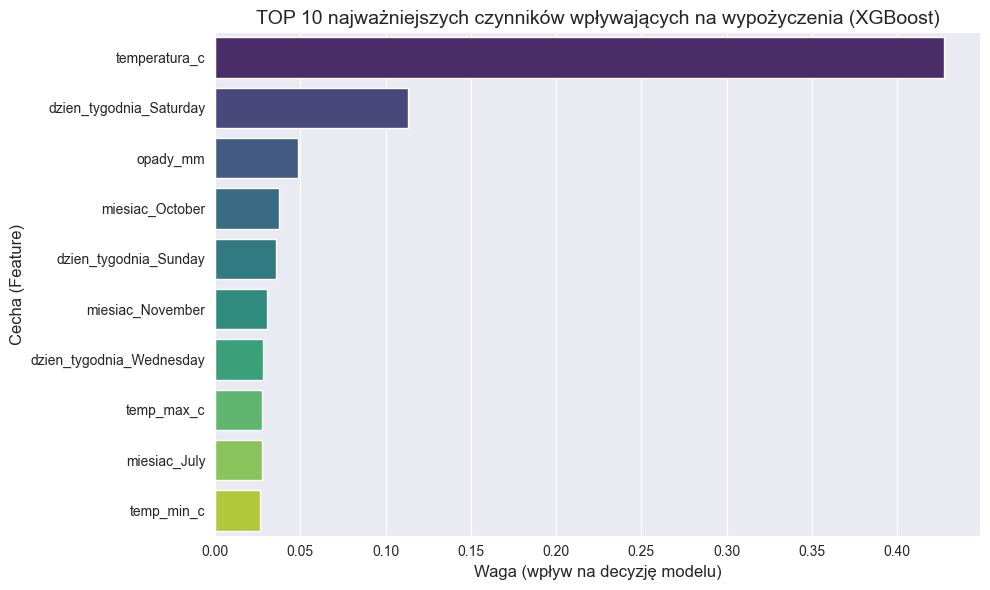

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wyciągnięcie wag z wytrenowanego modelu
waznosc_cech = model_xgb.feature_importances_
nazwy_cech = X.columns

df_waznosc = pd.DataFrame({'Cecha': nazwy_cech, 'Waznosc': waznosc_cech})
df_waznosc = df_waznosc.sort_values(by='Waznosc', ascending=False).head(10) # Bierzemy TOP 10

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
sns.barplot(data=df_waznosc, x='Waznosc', y='Cecha', hue='Cecha', palette='viridis', legend=False)

plt.title("TOP 10 najważniejszych czynników wpływających na wypożyczenia (XGBoost)", fontsize=14)
plt.xlabel("Waga (wpływ na decyzję modelu)", fontsize=12)
plt.ylabel("Cecha (Feature)", fontsize=12)
plt.tight_layout()

plt.savefig("feature_importance_xgboost.png")
plt.show()

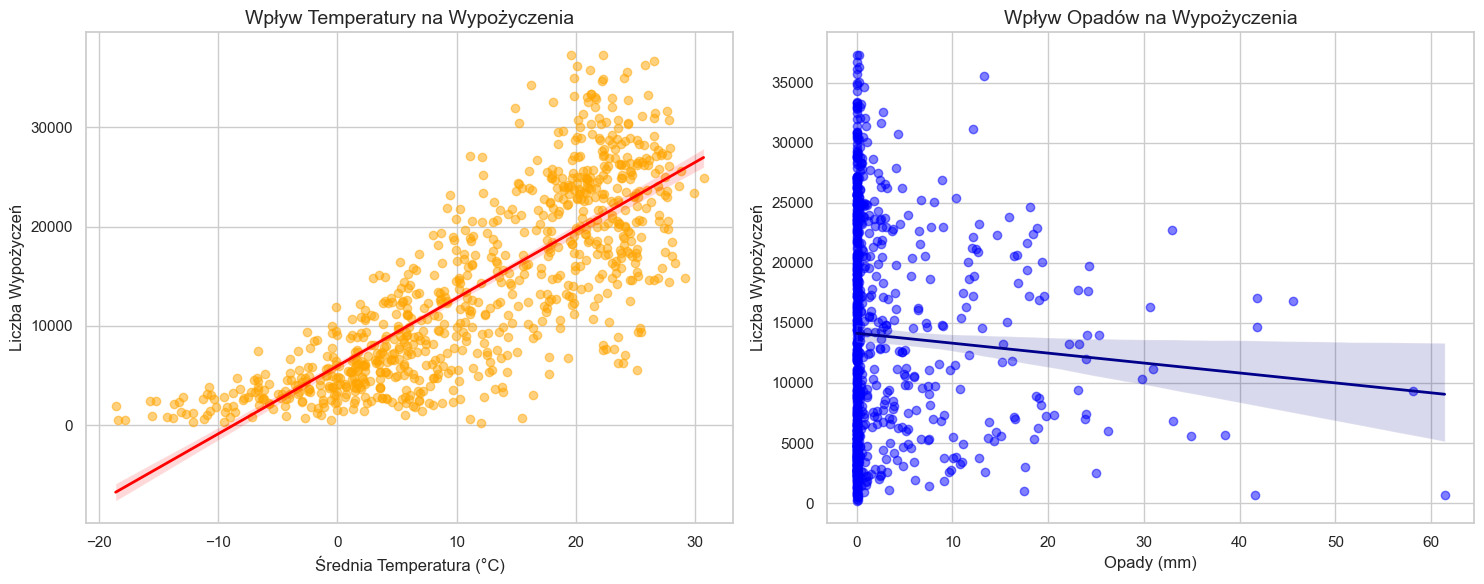

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_wykresy = pd.read_parquet("chicago_bikes_daily_master.parquet")
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Wykres 1: Temperatura
sns.regplot(data=df_wykresy, x='temperatura_c', y='liczba_wypozyczen', ax=ax1, 
            scatter_kws={'alpha': 0.5, 'color': 'orange'}, line_kws={'color': 'red', 'linewidth': 2})
ax1.set_title('Wpływ Temperatury na Wypożyczenia', fontsize=14)
ax1.set_xlabel('Średnia Temperatura (°C)', fontsize=12)
ax1.set_ylabel('Liczba Wypożyczeń', fontsize=12)

# Wykres 2: Opady
sns.regplot(data=df_wykresy, x='opady_mm', y='liczba_wypozyczen', ax=ax2, 
            scatter_kws={'alpha': 0.5, 'color': 'blue'}, line_kws={'color': 'darkblue', 'linewidth': 2})
ax2.set_title('Wpływ Opadów na Wypożyczenia', fontsize=14)
ax2.set_xlabel('Opady (mm)', fontsize=12)
ax2.set_ylabel('Liczba Wypożyczeń', fontsize=12)

plt.tight_layout()
plt.savefig('wplyw_pogody.png', dpi=300)
plt.show()